# SHAP-IMV — Titanic

Exact Shapley attribution with IMV as the coalition value, on the OpenML Titanic
dataset (binary: survived).

`Title` is extracted from the passenger name, so this specification includes the
eight-feature set used in the published figure. Note that `Title` is almost
perfectly nested inside `Sex`, and Shapley symmetry makes near-redundant features
share credit — expect the two to split attribution.

**Pipeline**: download from OpenML → preprocess → standardise → 5 seeds × 3
estimators × exact power set → aggregate.

Full documentation: `documentation/examples/shap_imv/titanic.md`.

In [1]:
%matplotlib inline
import os, warnings, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# No dataset is stored in this repository. Everything downloads on demand into a
# user-level cache outside the working tree.
CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
CACHE.mkdir(parents=True, exist_ok=True)

DATA_HOME = Path(os.environ.get("IMV_DATA_CACHE", CACHE / "datasets")) / "openml"
ARTIFACTS = Path(os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts")) / "shap_imv_titanic"
RESULTS = ARTIFACTS / "results"; RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES = ARTIFACTS / "figures"; FIGURES.mkdir(parents=True, exist_ok=True)

# Five seeds, as required for any reported IMV result. The seed drives the fold
# split and the estimator, so every number below is a mean over five independent
# fold partitions.
SEEDS = [42, 43, 44, 45, 46]
N_SPLITS = 5

import imv
from imv import BinaryIMV
from imv.utils import save_figure

# Fail fast if Jupyter is attached to a different installation of imv.
_HERE = Path().resolve()
REPOSITORY_ROOT = next((path for path in (_HERE, *_HERE.parents)
                        if (path / "pyproject.toml").is_file()
                        and (path / "src" / "imv").is_dir()), None)
if REPOSITORY_ROOT is None:
    raise RuntimeError("Run this notebook from inside the imv repository checkout.")
IMV_SOURCE = Path(imv.__file__).resolve().parent
EXPECTED_IMV_SOURCE = (REPOSITORY_ROOT / "src" / "imv").resolve()
if IMV_SOURCE != EXPECTED_IMV_SOURCE:
    raise RuntimeError(f"Expected repository package at {EXPECTED_IMV_SOURCE}, imported {IMV_SOURCE}")
print(f"imv {imv.__version__} from {IMV_SOURCE}")


imv 1.2.0 from /home/jinx/CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/github/imv_ml_package/src/imv


## 1. Download

Nothing is read from the repository.

In [2]:
from sklearn.datasets import fetch_openml
DATASET, TITLE = "titanic", "Titanic"
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    frame = fetch_openml("titanic", version=1, as_frame=True,
                         data_home=DATA_HOME).frame.copy()
print(frame.shape, list(frame.columns))
frame.head()

(1309, 14) ['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## 2. Preprocess

Every transformation is applied here and stated in the docs.

In [3]:
frame["target"] = frame["survived"].astype(int)
frame["Sex"] = (frame["sex"].astype(str) == "female").astype(int)
frame["Class"] = pd.to_numeric(frame["pclass"], errors="coerce")
frame["Age"] = pd.to_numeric(frame["age"], errors="coerce")
frame["Age"] = frame["Age"].fillna(frame["Age"].median())
frame["Fare"] = pd.to_numeric(frame["fare"], errors="coerce")
frame["Fare"] = frame["Fare"].fillna(frame["Fare"].median())
frame["Alone"] = ((pd.to_numeric(frame["sibsp"], errors="coerce").fillna(0)
                   + pd.to_numeric(frame["parch"], errors="coerce").fillna(0)) == 0).astype(int)
frame["Embarked"] = frame["embarked"].astype(str).map({"C": 0, "Q": 1, "S": 2}).fillna(2)
frame["AgeClass"] = frame["Age"] * frame["Class"]

# Title from the name field. The published figure's encoding was never recorded,
# so this ordering is our own and is documented rather than inferred.
title = frame["name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
title = title.replace(["Lady","Countess","Capt","Col","Don","Dr","Major","Rev",
                       "Sir","Jonkheer","Dona"], "Rare")
title = title.replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
frame["Title"] = title.map({"Mr":1,"Miss":2,"Mrs":3,"Master":4,"Rare":5}).fillna(0).astype(int)

FEATURES = ["Sex","Title","Class","AgeClass","Fare","Embarked"]
data = frame[FEATURES + ["target"]].apply(pd.to_numeric, errors="coerce").dropna()
print(data.shape, "positive rate:", round(data["target"].mean(), 4))
print("Title vs Sex (redundancy check):")
print(pd.crosstab(data["Title"], data["Sex"]))
data.head()

(1309, 7) positive rate: 0.382
Title vs Sex (redundancy check):
Sex      0    1
Title          
1      757    0
2        0  264
3        0  198
4       61    0
5       25    4


,Sex,Title,Class,AgeClass,Fare,Embarked,target
0,1,2,1,29.0000,211.3375,2.0,1
1,0,4,1,0.9167,151.5500,2.0,1
2,1,2,1,2.0000,151.5500,2.0,0
3,0,1,1,30.0000,151.5500,2.0,0
4,1,3,1,25.0000,151.5500,2.0,0


## 3. Estimators and budget

In [4]:
# Exact SHAP-IMV enumerates every feature subset, so cost is
# 2**n_features * n_splits * 2 fits per seed per estimator. Rows are capped at
# 4000 (stratified, seeded) to keep that affordable; this is an example budget,
# not a methodological recommendation.
MAX_ROWS = 4000

def subsample(frame, target, seed):
    if len(frame) <= MAX_ROWS:
        return frame.reset_index(drop=True)
    per_class = frame.groupby(target, group_keys=False)
    frac = MAX_ROWS / len(frame)
    out = per_class.apply(lambda g: g.sample(frac=frac, random_state=seed))
    return out.reset_index(drop=True)

def model_factories(seed):
    """Three estimator families, deliberately small so the exact power set is affordable."""
    return {
        "logistic_regression": lambda: LogisticRegression(max_iter=5000, random_state=seed),
        "xgboost": lambda: XGBClassifier(
            n_estimators=60, max_depth=3, learning_rate=0.2, random_state=seed,
            verbosity=0, tree_method="hist", n_jobs=1),
        "lightgbm": lambda: LGBMClassifier(
            n_estimators=60, max_depth=3, learning_rate=0.2, random_state=seed,
            verbose=-1, n_jobs=1),
    }


## 4. Exact SHAP-IMV over five seeds

Each value is a mean over five independent fold partitions; `std` is the spread across seeds, which describes stability and is **not** a confidence interval.

In [5]:
# Features are standardised because IMV reads probabilities, and unscaled inputs
# leave logistic regression unconverged, which would score a half-optimised model.
def scaled(frame, features):
    out = frame.copy()
    out[features] = StandardScaler().fit_transform(out[features])
    return out

records = []
for seed in SEEDS:
    frame = scaled(subsample(data, "target", seed), FEATURES)
    for name, factory in model_factories(seed).items():
        evaluator = BinaryIMV(
            frame, "target", FEATURES, factory,
            split_method="stratified_kfold", n_splits=N_SPLITS,
            random_seed=seed, n_jobs=1,
        )
        evaluator.run_evaluation()
        for feature in FEATURES:
            records.append({
                "seed": seed, "model": name, "feature": feature,
                "shap_imv": evaluator.calculate_imvshapley_value(feature),
            })
        records.append({
            "seed": seed, "model": name, "feature": "__full_model_imv__",
            "shap_imv": evaluator.all_combinations_imv[tuple(FEATURES)][0],
        })

raw = pd.DataFrame(records)
raw.to_csv(RESULTS / f"{DATASET}_shap_imv_by_seed.csv", index=False)
summary = (raw[raw.feature != "__full_model_imv__"]
           .groupby(["model", "feature"])["shap_imv"]
           .agg(["mean", "std"]).reset_index()
           .sort_values(["model", "mean"], ascending=[True, False]))
summary.to_csv(RESULTS / f"{DATASET}_shap_imv_summary.csv", index=False)
summary


  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

...

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

,model,feature,mean,std
5,lightgbm,Title,0.1172,0.001095
4,lightgbm,Sex,0.1066,0.001817
3,lightgbm,Fare,0.0566,0.001817
1,lightgbm,Class,0.0492,0.001304
0,lightgbm,AgeClass,0.0256,0.003362
2,lightgbm,Embarked,0.0126,0.002302
10,logistic_regression,Sex,0.1510,0.001871
11,logistic_regression,Title,0.0692,0.001789
7,logistic_regression,Class,0.0414,0.000548
6,logistic_regression,AgeClass,0.0392,0.000837


## 5. Figure

A negative bar means the feature *reduced* held-out information — it does not indicate the negative class.

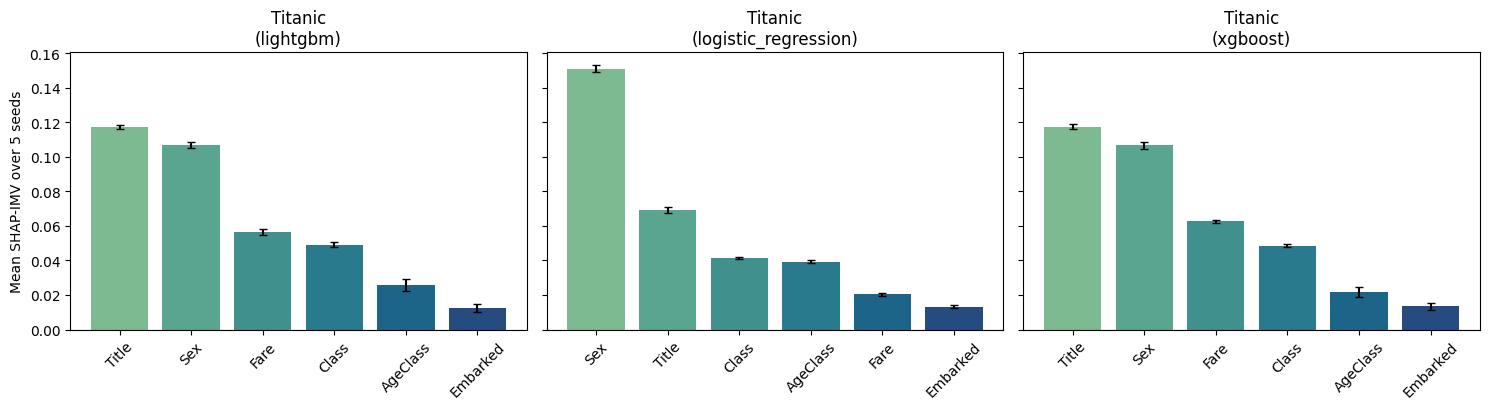

{'png': PosixPath('/tmp/imv-external-cache/notebook_artifacts/shap_imv_titanic/figures/titanic_shap_imv.png'),
 'pdf': PosixPath('/tmp/imv-external-cache/notebook_artifacts/shap_imv_titanic/figures/titanic_shap_imv.pdf'),
 'svg': PosixPath('/tmp/imv-external-cache/notebook_artifacts/shap_imv_titanic/figures/titanic_shap_imv.svg')}

In [6]:
models = list(summary["model"].unique())
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4.2), sharey=True)
axes = np.atleast_1d(axes)
for ax, name in zip(axes, models):
    part = summary[summary.model == name].sort_values("mean", ascending=False)
    ax.bar(part["feature"], part["mean"], yerr=part["std"].fillna(0),
           capsize=3, color=sns.color_palette("crest", len(part)))
    ax.set_title(f"{TITLE}\n({name})")
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(0, color="0.4", linewidth=0.8)
axes[0].set_ylabel(f"Mean SHAP-IMV over {len(SEEDS)} seeds")
fig.tight_layout()
paths = save_figure(fig, FIGURES / f"{DATASET}_shap_imv")
plt.show()
paths
